cuda


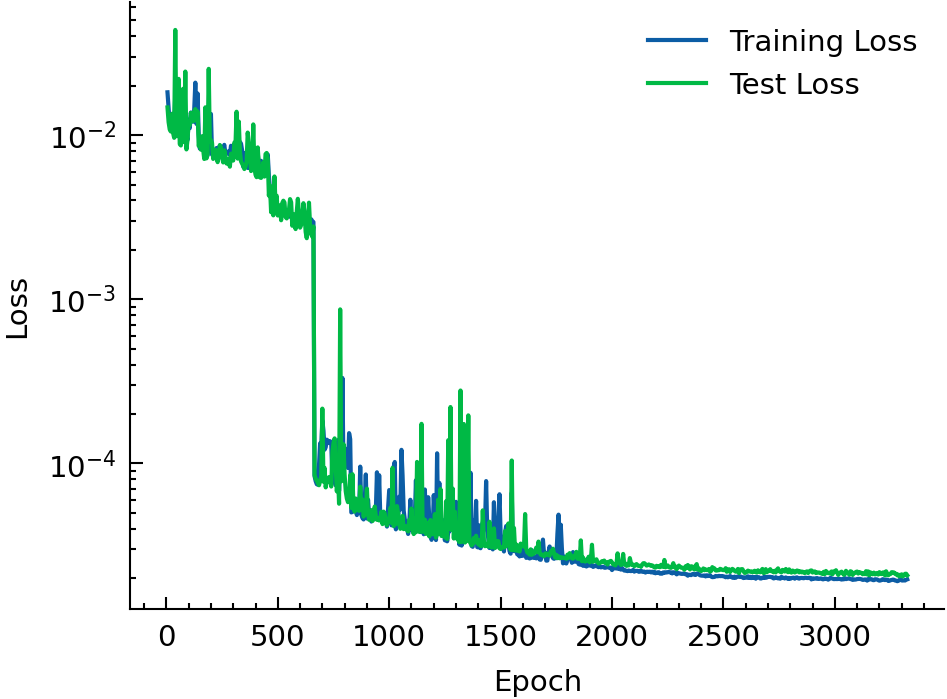

In [1]:
%reset -f

import torch
import numpy as np
from plpm import numerical_solver, calculate_PLV
from plpm import ModelWrapper, InverseModelingExpData
from plpm import MainPlots, InverseModelingPlots
import matplotlib.pyplot as plt
from plpm.constants.BaselineCase import base
from pkg_resources import resource_stream
import time

space_dim = 10
model_file = 'MainModel10DFinal'

main_model = ModelWrapper.Model(model_file=model_file, d=space_dim)
loss_file = 'losses10DFinal'

figures = MainPlots()
figures.plot_loss(loss_file)

num_timepoints =  251


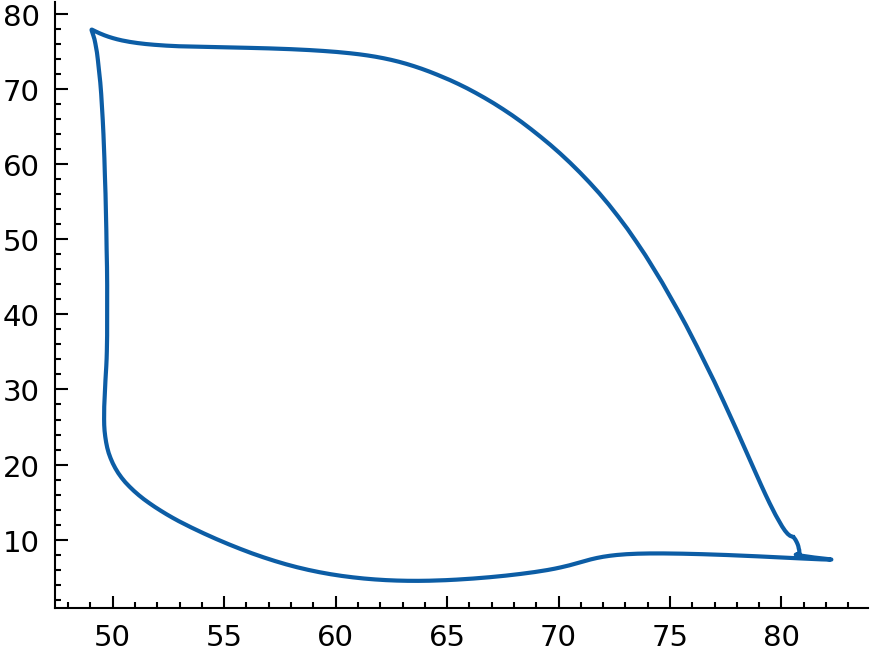

In [2]:
data = np.loadtxt(resource_stream(
    'plpm', '../data/ExperimentalData/processed/pig924baseline.csv'),
    delimiter=",", skiprows=1)

num_timepoints = data.shape[0]
num_cols = data.shape[1]
print('num_timepoints = ', num_timepoints)
from scipy.interpolate import interp1d



interpolated_data = np.zeros((2 * num_timepoints, num_cols))
for col in range(num_cols):
    interp_func = interp1d(np.arange(num_timepoints), data[:, col], kind='linear')
    interpolated_data[:, col] = interp_func(np.linspace(0, num_timepoints - 1, 2 * num_timepoints))

plt.plot(interpolated_data[:, 1:2], interpolated_data[:, 2:3])

In [3]:
inverse_modeling = InverseModelingExpData(model=main_model,
                                          data=interpolated_data[:, :3])
bounds = [(0.3, 3.), (0.3, 3.), (0.3, 3.), (0.3, 3.), (0.3, 3.),
          (0.3, 3.), (0.3, 3.), (0.3, 3.), (0.3, 3.), (0.7, 1.35)]
start = time.time()
CASE_Estimated = inverse_modeling(bounds, seed=45, popsize=50,
                                  strategy='best1bin', maxiter=100, disp=True)
print(CASE_Estimated)
print(f"Elapsed time: {time.time() - start} seconds")

V_LV loaded
P_LV loaded
differential_evolution step 1: f(x)= 0.189498
differential_evolution step 2: f(x)= 0.128344
differential_evolution step 3: f(x)= 0.128344
differential_evolution step 4: f(x)= 0.128344
differential_evolution step 5: f(x)= 0.106025
differential_evolution step 6: f(x)= 0.106025
differential_evolution step 7: f(x)= 0.106025
differential_evolution step 8: f(x)= 0.105536
differential_evolution step 9: f(x)= 0.0906355
differential_evolution step 10: f(x)= 0.0906355
differential_evolution step 11: f(x)= 0.0877439
differential_evolution step 12: f(x)= 0.0877439
differential_evolution step 13: f(x)= 0.0876859
differential_evolution step 14: f(x)= 0.0876859
differential_evolution step 15: f(x)= 0.0876859
differential_evolution step 16: f(x)= 0.0793997
differential_evolution step 17: f(x)= 0.0775972
differential_evolution step 18: f(x)= 0.0775972
differential_evolution step 19: f(x)= 0.0775972
differential_evolution step 20: f(x)= 0.0725487
differential_evolution step 21: f

In [4]:
CASE = CASE_Estimated
mR_av, mR_ao, mC_ao, mR_art, mC_art, mR_vc, mC_vc, mR_mv, mEes_lv, mtrans_lv = torch.split(CASE.squeeze(), 1, dim=0)

In [5]:
V_pinn = main_model.predict_CASE(CASE_Estimated)
plv_pinn = calculate_PLV(V_pinn[:, 0], mEes_lv, mtrans_lv)

In [6]:
inverse_figures = InverseModelingPlots(data)
V_pinn_metric = main_model.predict_CASE(CASE_Estimated, nt=torch.from_numpy(data[:, 0:1]) / base.Tc)
plv_pinn_metric = calculate_PLV(V_pinn_metric[:, 0], mEes_lv, mtrans_lv)

def metric(estimated, true):
    ss_res = torch.sum(torch.square(estimated - true))
    true_mean = true.mean()
    ss_tot = torch.sum(torch.square(true - true_mean))
    return 1 - ss_res / ss_tot
vlv_true = torch.from_numpy(data[:, 1])
VLV_error = metric(V_pinn_metric[:, 0], vlv_true)

plv_true = torch.from_numpy(data[:, 2])
plv_error = metric(plv_pinn_metric, plv_true)

metrics = torch.tensor([VLV_error, plv_error])

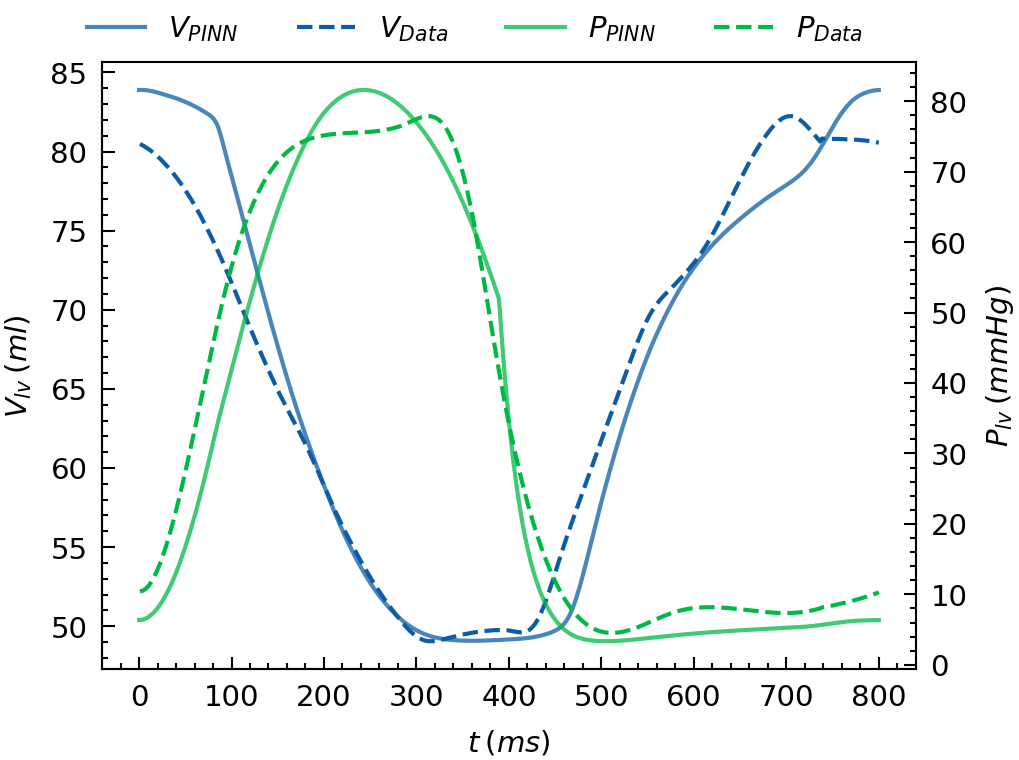

In [7]:
inverse_figures.plot_publication(V_pinn[:, 0], plv_pinn)

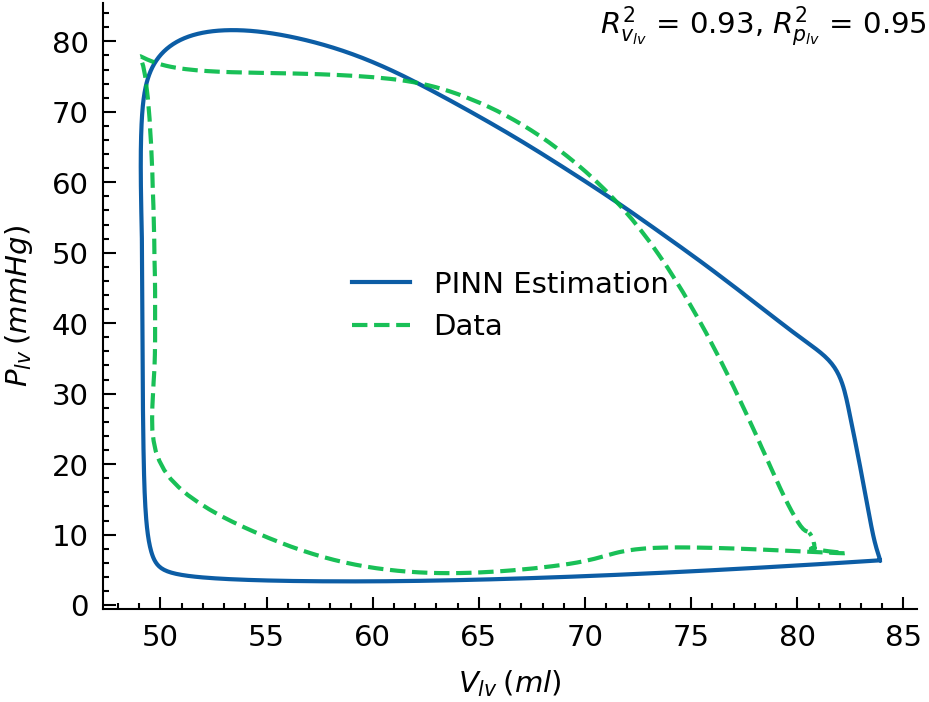

In [8]:
inverse_figures.plot_PVloop(V_pinn[:, 0], plv_pinn, metric=metrics, metric_pos=torch.tensor([0.61, 0.95]))

In [15]:
C_ao = base.C_ao * mC_ao
pao_pinn = (V_pinn[:, 1:2] - base.v_ao_r) / C_ao
pao_pinn *= 0.0075

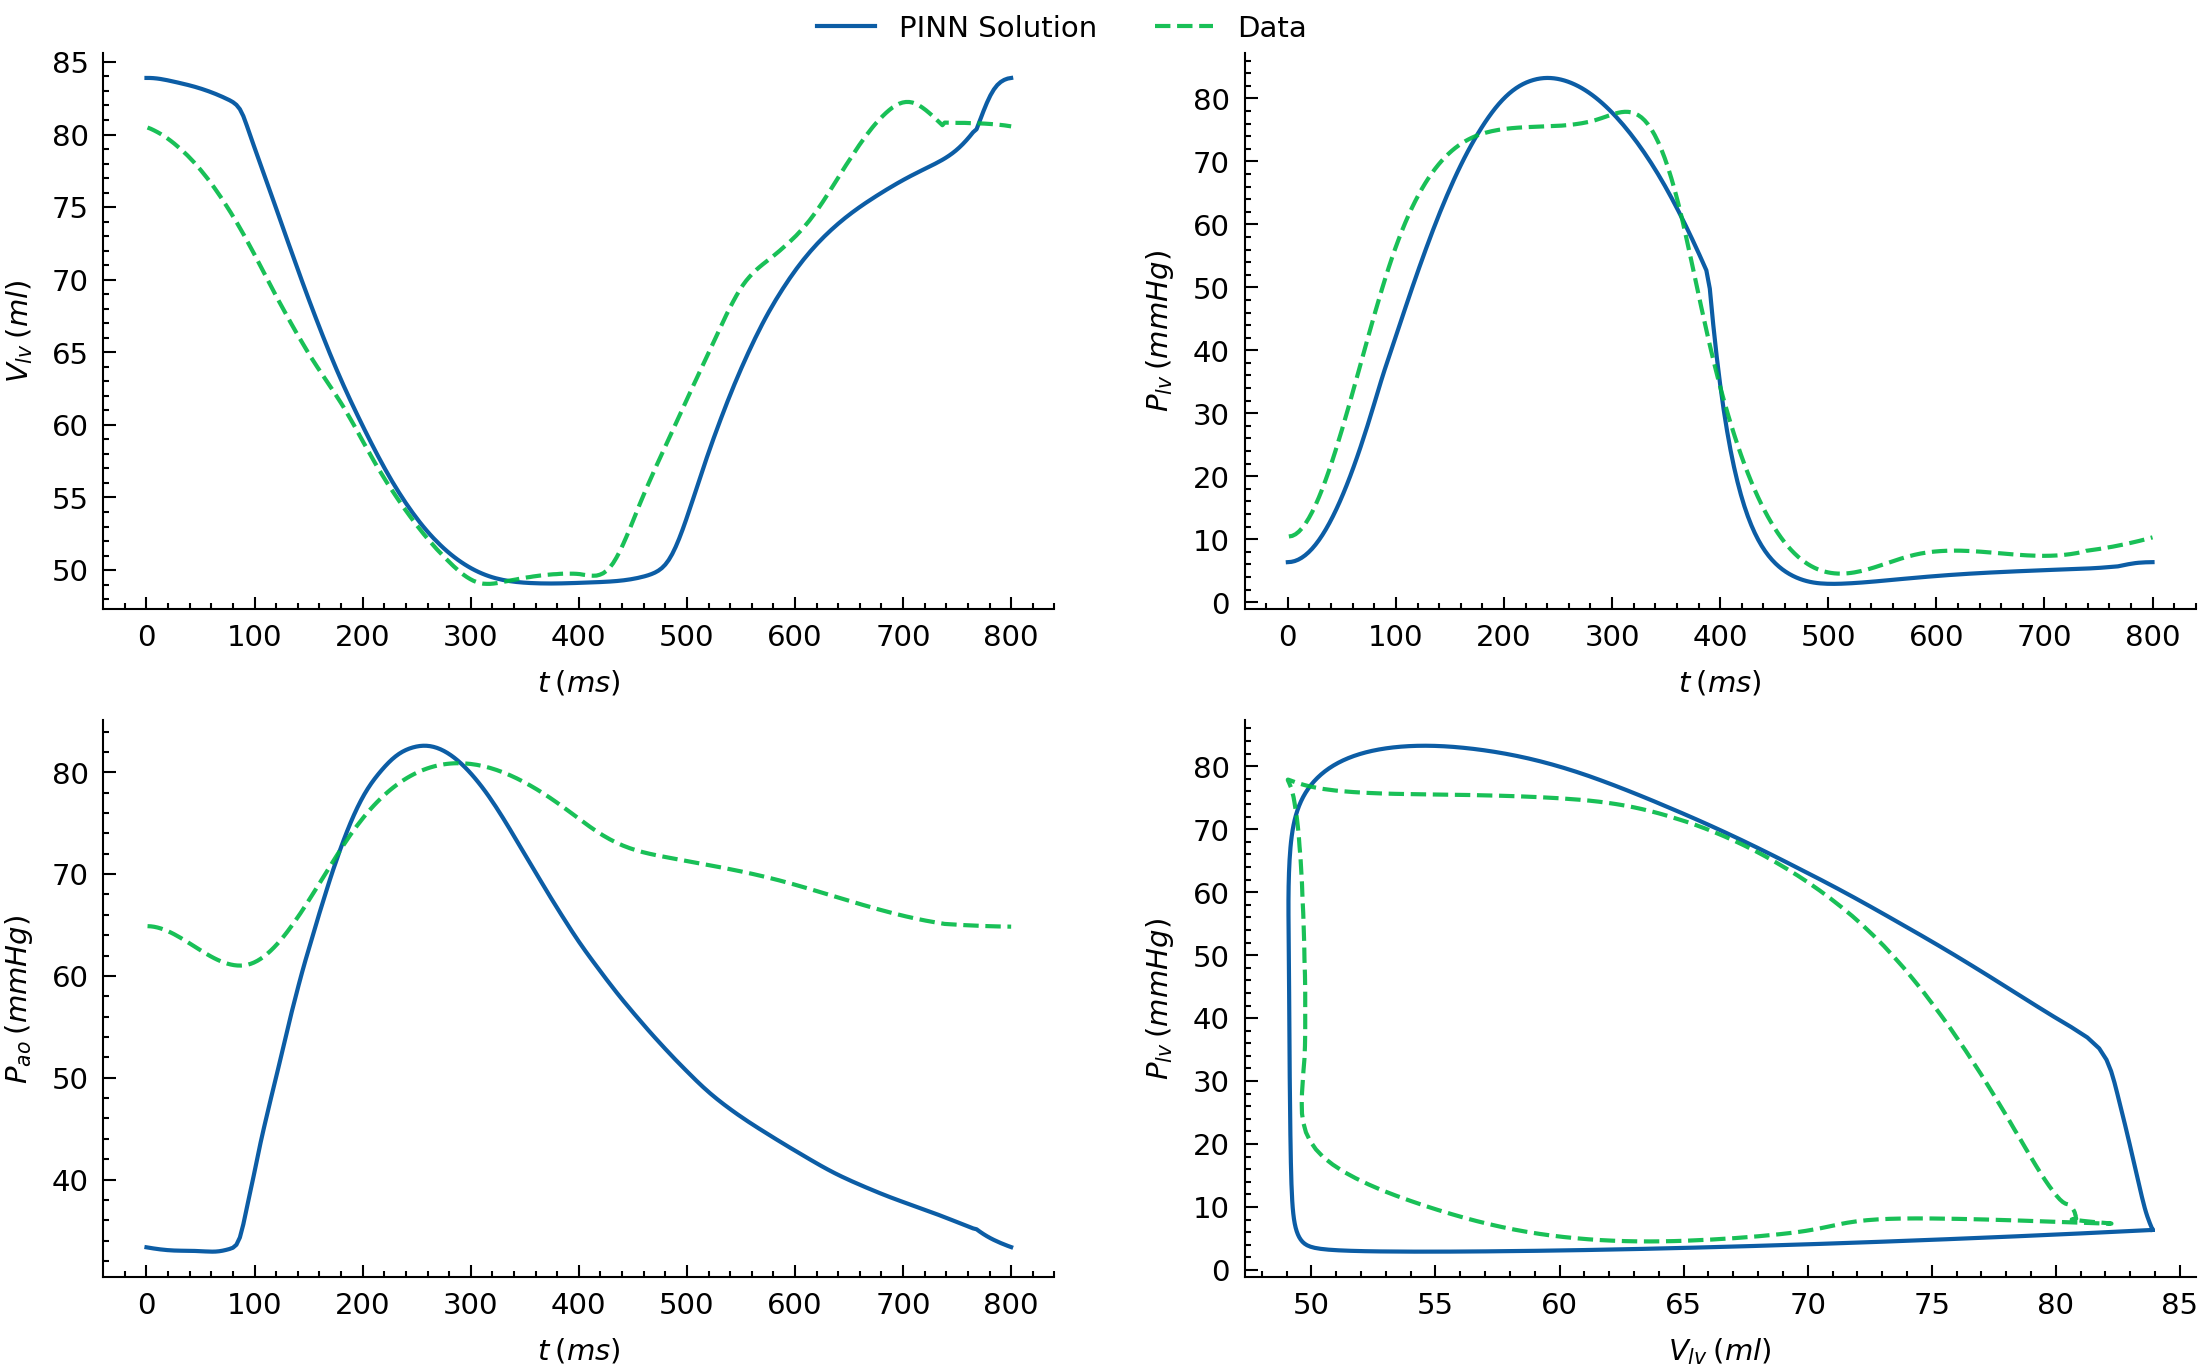

In [14]:
inverse_figures.plot_CASE_together(V_pinn[:, 0],
                                   plv_pinn,
                                   pao_pinn)

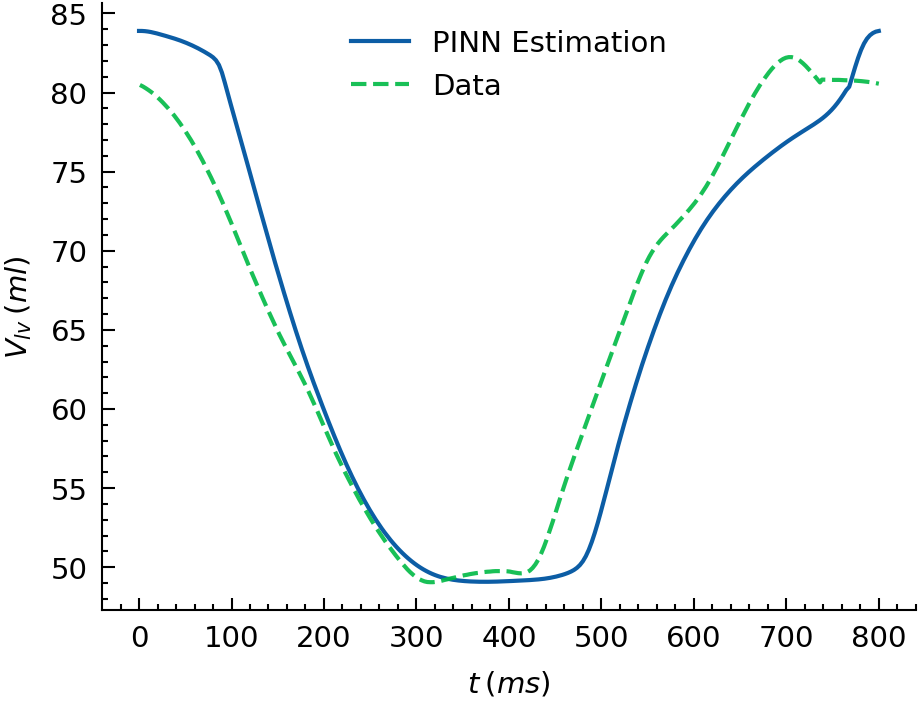

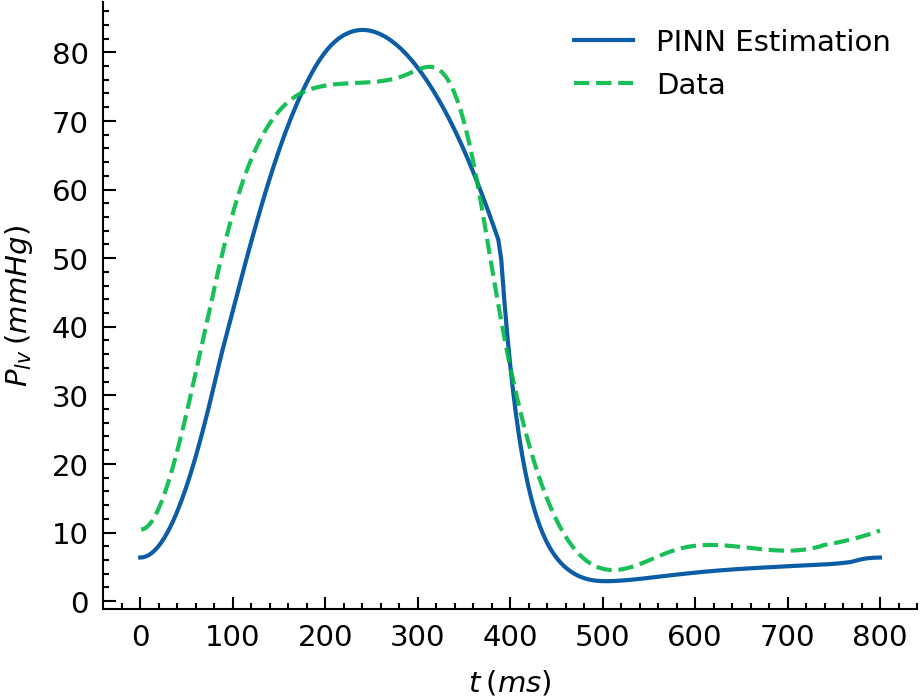

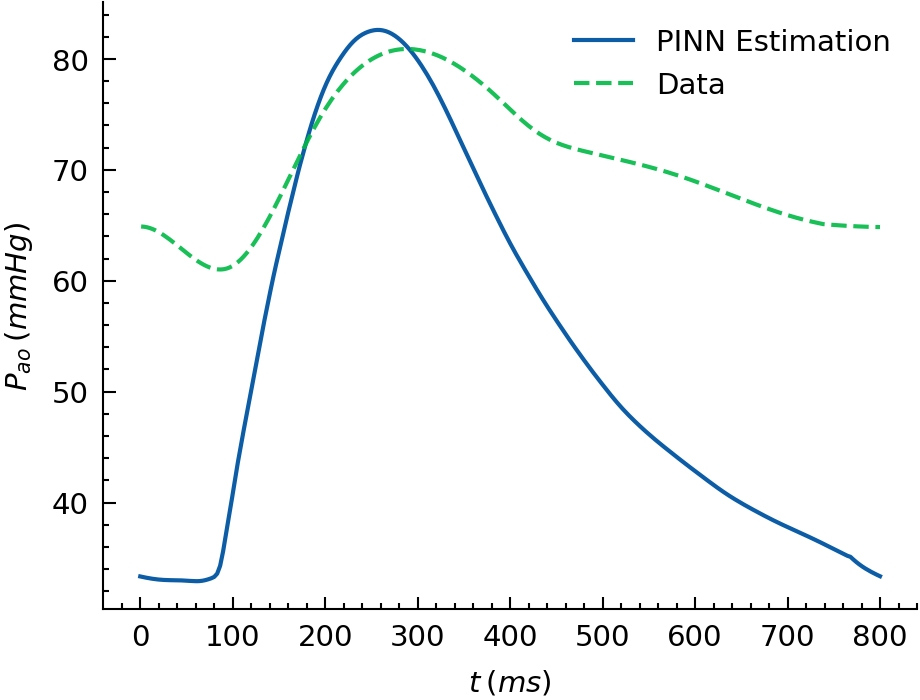

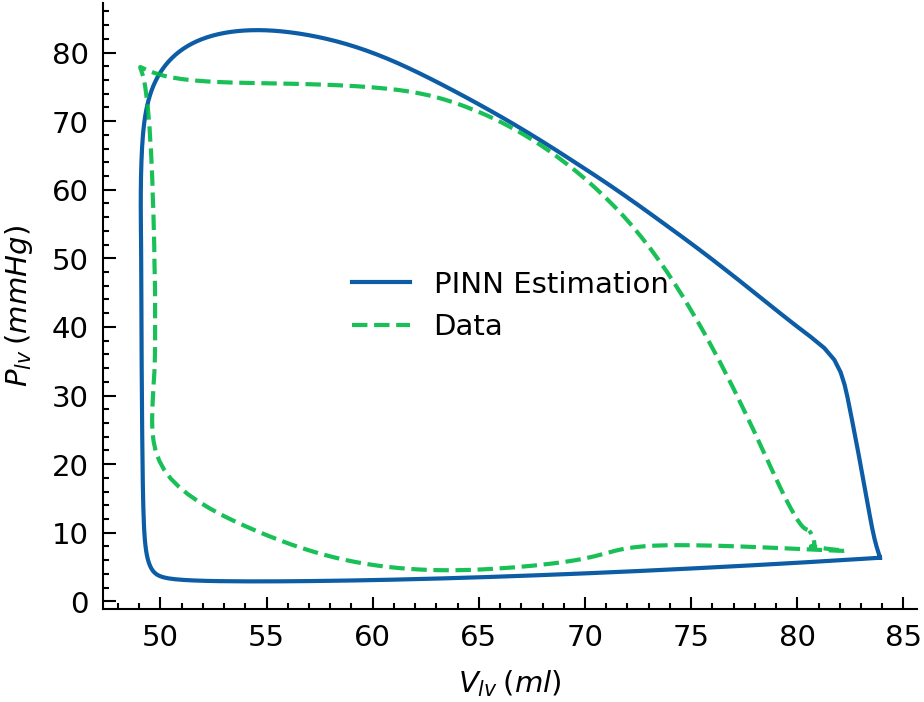

In [17]:
inverse_figures = InverseModelingPlots(data)
inverse_figures.plot_VLV(V_pinn[:, 0])
inverse_figures.plot_PLV(plv_pinn)
inverse_figures.plot_Pao(pao_pinn)
inverse_figures.plot_PVloop(vlv_pinn=V_pinn[:, 0], plv_pinn=plv_pinn)